In [2]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


In [3]:
df1 = pd.read_csv("../data/Matched_WQ_S2_1.csv")
df2 = pd.read_csv("../data/Matched_WQ_S2_2.csv")
df = pd.concat([df1, df2], ignore_index=True)

print("Combined shape:", df.shape)


C:\Users\Netra vora\AppData\Local\Temp\ipykernel_28188\898667582.py:1: DtypeWarning: Columns (0: DepthCd, 1: DepthUnits, 2: nhd_identifier) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("../data/Matched_WQ_S2_1.csv")
C:\Users\Netra vora\AppData\Local\Temp\ipykernel_28188\898667582.py:2: DtypeWarning: Columns (0: DepthCd, 1: DepthPcode, 2: DepthUnits, 3: nhd_identifier) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("../data/Matched_WQ_S2_2.csv")


Combined shape: (1748467, 85)


In [4]:
df_usable = df[df["l2flag_center"] == 1].copy()
print("Usable rows:", df_usable.shape)


Usable rows: (566638, 85)


In [5]:
band_cols = ["B01_center", "B02_center", "B03_center", "B04_center", "B05_center",
             "B06_center", "B07_center", "B08_center", "B11_center", "B12_center", "B8A_center"]
buf_cols = [c.replace("_center", "_buf250_mean") for c in band_cols]
ratio_cols = ["ndti", "green_red_ratio", "nir_red_ratio"]
feature_cols = band_cols + buf_cols + ratio_cols

def add_features(d):
    d = d.copy()
    d["ndti"] = (d["B04_center"] - d["B03_center"]) / (d["B04_center"] + d["B03_center"])
    d["green_red_ratio"] = d["B03_center"] / d["B04_center"].replace(0, np.nan)
    d["nir_red_ratio"] = d["B08_center"] / d["B04_center"].replace(0, np.nan)
    return d


In [6]:
df_turbidity = df_usable[df_usable["parm_nm"].str.contains("Turbidity", na=False)]
print(df_turbidity.shape, df_turbidity["station_nm"].nunique(), "stations")


(250353, 85) 44 stations


In [7]:
turb_stations = df_turbidity["station_nm"].unique().tolist()
turb_train_stations, turb_test_stations = train_test_split(turb_stations, test_size=0.2, random_state=42)

turb_train_df = df_turbidity[df_turbidity["station_nm"].isin(turb_train_stations)]
turb_test_df = df_turbidity[df_turbidity["station_nm"].isin(turb_test_stations)]

print("Train:", turb_train_df.shape, turb_train_df["station_nm"].nunique(), "stations")
print("Test:", turb_test_df.shape, turb_test_df["station_nm"].nunique(), "stations")


Train: (203283, 85) 35 stations
Test: (47070, 85) 9 stations


In [8]:
turb_train_df = add_features(turb_train_df)
turb_test_df = add_features(turb_test_df)

X_train_turb = turb_train_df[feature_cols].fillna(0)
y_train_turb = np.log1p(turb_train_df["MeasurementValue"])

X_test_turb = turb_test_df[feature_cols].fillna(0)
y_test_turb = turb_test_df["MeasurementValue"]


In [9]:
turb_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
turb_model.fit(X_train_turb, y_train_turb)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [10]:
turb_pred = np.expm1(turb_model.predict(X_test_turb))

print("Turbidity R²:", r2_score(y_test_turb, turb_pred))
print("Turbidity MAE:", mean_absolute_error(y_test_turb, turb_pred))


Turbidity R²: 0.42333690032393423
Turbidity MAE: 10.417897267873947


In [11]:
turb_importances = pd.Series(turb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(turb_importances.head(10))


B05_buf250_mean    0.542812
nir_red_ratio      0.150272
green_red_ratio    0.044016
B04_buf250_mean    0.027057
ndti               0.026176
B12_buf250_mean    0.023740
B06_buf250_mean    0.019340
B04_center         0.016923
B01_center         0.016407
B02_center         0.015176
dtype: float64


In [12]:
joblib.dump(turb_model, "turbidity_model.pkl")
joblib.dump(feature_cols, "turbidity_features.pkl")
print("Saved turbidity model.")


Saved turbidity model.


## Chlorophyll and CDOM — investigated, not deployed
Despite feature engineering, cross-validation, per-basin modeling, and classification 
reframing, neither chlorophyll nor CDOM generalized reliably (see phase2-documentation.md 
for full methodology and results). No model is saved for either — the app ships turbidity only.

In [13]:
df_chlorophyll = df_usable[
    df_usable["parm_nm"].str.contains("Chlorophyll|fChl", na=False, case=False) &
    df_usable["parm_nm"].str.contains("micrograms per liter", na=False, case=False)
]
print(df_chlorophyll.shape, df_chlorophyll["station_nm"].nunique(), "stations")

(56561, 85) 18 stations


In [14]:
def add_features_v2(d):
    d = d.copy()
    d["ndti"] = (d["B04_center"] - d["B03_center"]) / (d["B04_center"] + d["B03_center"])
    d["green_red_ratio"] = d["B03_center"] / d["B04_center"].replace(0, np.nan)
    d["nir_red_ratio"] = d["B08_center"] / d["B04_center"].replace(0, np.nan)
    d["ndci"] = (d["B05_center"] - d["B04_center"]) / (d["B05_center"] + d["B04_center"])
    d["basin"] = d["huc4"].astype(str)
    return d

df_chlorophyll_feat = add_features_v2(df_chlorophyll)
df_chlorophyll_feat = pd.get_dummies(df_chlorophyll_feat, columns=["basin"], prefix="basin")

basin_cols = [c for c in df_chlorophyll_feat.columns if c.startswith("basin_")]
feature_cols_chl = feature_cols + ["ndci"] + basin_cols

X_all = df_chlorophyll_feat[feature_cols_chl].fillna(0)
y_all_log = np.log1p(df_chlorophyll_feat["MeasurementValue"].clip(lower=0))
y_all_real = df_chlorophyll_feat["MeasurementValue"].clip(lower=0)
groups = df_chlorophyll_feat["station_nm"]

In [15]:
from sklearn.model_selection import GroupKFold
import numpy as np

gkf = GroupKFold(n_splits=5)
all_true = []
all_pred = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_all, y_all_log, groups)):
    m = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
    m.fit(X_all.iloc[train_idx], y_all_log.iloc[train_idx])
    pred = np.expm1(m.predict(X_all.iloc[test_idx]))

    all_true.extend(y_all_real.iloc[test_idx].tolist())
    all_pred.extend(pred.tolist())

overall_r2 = r2_score(all_true, all_pred)
overall_mae = mean_absolute_error(all_true, all_pred)

print("Pooled R² across all folds:", overall_r2)
print("Pooled MAE across all folds:", overall_mae)

Pooled R² across all folds: -0.2510545392173371
Pooled MAE across all folds: 10.385619870805689


In [16]:
#trying using per basin technique ie giving each station seperate model
print(df_chlorophyll["huc4"].value_counts())
print()
print(df_chlorophyll.groupby("huc4")["station_nm"].nunique())

huc4
1709.0    19662
712.0     15203
1204.0    12864
713.0      7400
204.0      1432
Name: count, dtype: int64

huc4
204.0     2
712.0     5
713.0     3
1204.0    2
1709.0    6
Name: station_nm, dtype: int64


In [17]:
from sklearn.model_selection import GroupKFold

def evaluate_basin_group(df_subset, label):
    d = add_features_v2(df_subset)
    X = d[feature_cols + ["ndci"]].fillna(0)
    y_log = np.log1p(d["MeasurementValue"].clip(lower=0))
    y_real = d["MeasurementValue"].clip(lower=0)
    groups = d["station_nm"]

    n_stations = groups.nunique()
    n_splits = min(5, n_stations)  # can't have more folds than stations
    gkf = GroupKFold(n_splits=n_splits)

    all_true, all_pred = [], []
    for train_idx, test_idx in gkf.split(X, y_log, groups):
        m = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
        m.fit(X.iloc[train_idx], y_log.iloc[train_idx])
        pred = np.expm1(m.predict(X.iloc[test_idx]))
        all_true.extend(y_real.iloc[test_idx].tolist())
        all_pred.extend(pred.tolist())

    r2 = r2_score(all_true, all_pred)
    mae = mean_absolute_error(all_true, all_pred)
    print(f"{label}: R² = {r2:.3f}, MAE = {mae:.3f}, stations = {n_stations}, rows = {len(d)}")
    return r2, mae

# Basin 1709 — its own model
basin_1709 = df_chlorophyll[df_chlorophyll["huc4"] == 1709.0]
evaluate_basin_group(basin_1709, "Basin 1709 (Delaware)")

# Basin 712 — its own model
basin_712 = df_chlorophyll[df_chlorophyll["huc4"] == 712.0]
evaluate_basin_group(basin_712, "Basin 712")

# Basins 713 + 1204 + 204 — pooled "other" model
basin_other = df_chlorophyll[df_chlorophyll["huc4"].isin([713.0, 1204.0, 204.0])]
evaluate_basin_group(basin_other, "Other basins (pooled)")

Basin 1709 (Delaware): R² = -0.006, MAE = 2.848, stations = 6, rows = 19662
Basin 712: R² = -2.000, MAE = 11.770, stations = 5, rows = 15203
Other basins (pooled): R² = -1.430, MAE = 17.370, stations = 7, rows = 21696


(-1.4303100981994277, 17.37037751466349)

In [18]:
#Now classification model since all failed
# Define chlorophyll risk categories based on percentiles of the training data
df_chl_clf = add_features_v2(df_chlorophyll)
df_chl_clf["MeasurementValue"] = df_chl_clf["MeasurementValue"].clip(lower=0)

q1 = df_chl_clf["MeasurementValue"].quantile(0.33)
q2 = df_chl_clf["MeasurementValue"].quantile(0.66)
print("Low/Medium boundary:", q1)
print("Medium/High boundary:", q2)

def categorize(val):
    if val <= q1:
        return "Low"
    elif val <= q2:
        return "Medium"
    else:
        return "High"

df_chl_clf["risk_level"] = df_chl_clf["MeasurementValue"].apply(categorize)
print(df_chl_clf["risk_level"].value_counts())

Low/Medium boundary: 2.59
Medium/High boundary: 10.735999999999986
risk_level
High      19231
Low       18668
Medium    18662
Name: count, dtype: int64


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

feature_cols_clf = feature_cols + ["ndci"]
X_all = df_chl_clf[feature_cols_clf].fillna(0)
y_all = df_chl_clf["risk_level"]
groups = df_chl_clf["station_nm"]

gkf = GroupKFold(n_splits=5)
all_true, all_pred = [], []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_all, y_all, groups)):
    clf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
    clf.fit(X_all.iloc[train_idx], y_all.iloc[train_idx])
    pred = clf.predict(X_all.iloc[test_idx])

    all_true.extend(y_all.iloc[test_idx].tolist())
    all_pred.extend(pred.tolist())

print("Overall accuracy:", accuracy_score(all_true, all_pred))
print()
print(classification_report(all_true, all_pred))
print()
print("Confusion matrix (rows=actual, cols=predicted):")
print(confusion_matrix(all_true, all_pred, labels=["Low", "Medium", "High"]))

Overall accuracy: 0.30706670674139425

              precision    recall  f1-score   support

        High       0.17      0.12      0.14     19231
         Low       0.49      0.58      0.53     18668
      Medium       0.21      0.24      0.22     18662

    accuracy                           0.31     56561
   macro avg       0.29      0.31      0.30     56561
weighted avg       0.29      0.31      0.29     56561


Confusion matrix (rows=actual, cols=predicted):
[[10746  3509  4413]
 [ 7376  4386  6900]
 [ 3840 13155  2236]]


In [20]:
df_cdom = df_usable[df_usable["parm_nm"].str.contains("fDOM", na=False)]

print(df_cdom.shape, df_cdom["station_nm"].nunique(), "stations")
print(df_cdom["parm_nm"].value_counts())
print()
print(df_cdom["MeasurementValue"].describe())

(52744, 85) 7 stations
parm_nm
Dissolved organic matter fluorescence (fDOM), water, in situ, concentration estimated from reference material, micrograms per liter as quinine sulfate equivalents (QSE)    35144
Dissolved organic matter relative fluorescence (fDOM), water, in situ, relative fluorescence units (RFU)                                                                    17600
Name: count, dtype: int64

count    52744.000000
mean        20.088315
std         15.234377
min          0.620000
25%          9.210000
50%         12.980000
75%         30.700000
max         70.260000
Name: MeasurementValue, dtype: float64


In [21]:
df_cdom_ugl = df_usable[
    df_usable["parm_nm"].str.contains("fDOM", na=False) &
    df_usable["parm_nm"].str.contains("micrograms per liter", na=False)
]

print(df_cdom_ugl.shape, df_cdom_ugl["station_nm"].nunique(), "stations")

(35144, 85) 7 stations


In [22]:
df_cdom_feat = add_features_v2(df_cdom_ugl)

feature_cols_cdom = feature_cols + ["ndci"]
X_all = df_cdom_feat[feature_cols_cdom].fillna(0)
y_all_log = np.log1p(df_cdom_feat["MeasurementValue"].clip(lower=0))
y_all_real = df_cdom_feat["MeasurementValue"].clip(lower=0)
groups = df_cdom_feat["station_nm"]

n_stations = groups.nunique()
n_splits = min(5, n_stations)
gkf = GroupKFold(n_splits=n_splits)

all_true, all_pred = [], []
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_all, y_all_log, groups)):
    m = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
    m.fit(X_all.iloc[train_idx], y_all_log.iloc[train_idx])
    pred = np.expm1(m.predict(X_all.iloc[test_idx]))

    all_true.extend(y_all_real.iloc[test_idx].tolist())
    all_pred.extend(pred.tolist())

print("Pooled R²:", r2_score(all_true, all_pred))
print("Pooled MAE:", mean_absolute_error(all_true, all_pred))

Pooled R²: -0.07804697294875029
Pooled MAE: 13.72120728331673


In [23]:
#adding more features and using outlier tracking
# ---------- Enhanced feature set: add std and median buffer columns ----------
band_cols_full = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B11", "B12", "B8A"]

center_cols = [f"{b}_center" for b in band_cols_full]
buf_mean_cols = [f"{b}_buf250_mean" for b in band_cols_full]
buf_std_cols = [f"{b}_buf250_std" for b in band_cols_full]
buf_med_cols = [f"{b}_buf250_med" for b in band_cols_full]
ratio_cols = ["ndti", "green_red_ratio", "nir_red_ratio"]

feature_cols_v3 = center_cols + buf_mean_cols + buf_std_cols + buf_med_cols + ratio_cols

# ---------- Outlier capping: clip extreme turbidity values before log-transform ----------
cap_value = df_turbidity["MeasurementValue"].quantile(0.99)
print("99th percentile turbidity value (cap):", cap_value)

turb_train_df_v3 = add_features(turb_train_df).copy()
turb_test_df_v3 = add_features(turb_test_df).copy()

turb_train_df_v3["MeasurementValue_capped"] = turb_train_df_v3["MeasurementValue"].clip(upper=cap_value)
# Note: we cap the TRAINING target only — test set stays uncapped so evaluation reflects real-world extreme cases

X_train_v3 = turb_train_df_v3[feature_cols_v3].fillna(0)
y_train_v3 = np.log1p(turb_train_df_v3["MeasurementValue_capped"])

X_test_v3 = turb_test_df_v3[feature_cols_v3].fillna(0)
y_test_v3 = turb_test_df_v3["MeasurementValue"]  # uncapped, real values

# ---------- Train and evaluate ----------
model_v3 = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
model_v3.fit(X_train_v3, y_train_v3)

pred_v3 = np.expm1(model_v3.predict(X_test_v3))

print("R²:", r2_score(y_test_v3, pred_v3))
print("MAE:", mean_absolute_error(y_test_v3, pred_v3))

99th percentile turbidity value (cap): 157.0
R²: 0.4254092956063843
MAE: 10.418967211149376


In [24]:
importances_v3 = pd.Series(model_v3.feature_importances_, index=feature_cols_v3).sort_values(ascending=False)
print(importances_v3.head(10))

B05_buf250_mean    0.526170
nir_red_ratio      0.147019
ndti               0.037878
green_red_ratio    0.028967
B04_buf250_mean    0.020780
B05_buf250_med     0.018755
B02_center         0.013420
B01_buf250_mean    0.011977
B12_buf250_med     0.011301
B05_center         0.011142
dtype: float64


In [25]:
#trying with XGBoost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_v3, y_train_v3)

xgb_pred = np.expm1(xgb_model.predict(X_test_v3))

print("XGBoost R²:", r2_score(y_test_v3, xgb_pred))
print("XGBoost MAE:", mean_absolute_error(y_test_v3, xgb_pred))

XGBoost R²: 0.40609915429137733
XGBoost MAE: 9.782416600510905


In [26]:
ensemble_pred = (pred_v3 + xgb_pred) / 2

print("Ensemble R²:", r2_score(y_test_v3, ensemble_pred))
print("Ensemble MAE:", mean_absolute_error(y_test_v3, ensemble_pred))

Ensemble R²: 0.42309544360319695
Ensemble MAE: 9.874057582196196


In [27]:
joblib.dump(model_v3, "turbidity_model.pkl")
joblib.dump(feature_cols_v3, "turbidity_features.pkl")
print("Saved final turbidity model (v3: richer features + outlier capping)")

Saved final turbidity model (v3: richer features + outlier capping)


In [28]:
import ee
import geemap

ee.Initialize(project='water-quality-monitor-509313')

def get_water_mask(lat, lon, start_date, end_date, max_cloud_pct=10):
    point = ee.Geometry.Point([lon, lat])

    collection = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(point)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", max_cloud_pct))
        .sort("CLOUDY_PIXEL_PERCENTAGE")
    )

    image = collection.first()
    if image is None:
        raise ValueError("No suitable Sentinel-2 image found for this location/date range.")

    ndwi = image.normalizedDifference(["B3", "B8"]).rename("NDWI")
    water_mask = ndwi.gt(0).selfMask()

    return {
        "image": image,
        "ndwi": ndwi,
        "water_mask": water_mask,
        "point": point,
        "date": image.date().format("YYYY-MM-dd").getInfo(),
        "cloud_pct": image.get("CLOUDY_PIXEL_PERCENTAGE").getInfo(),
    }


def extract_reflectance_features(image, water_mask, region, scale=10):
    bands = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B11", "B12", "B8A"]
    masked_image = image.updateMask(water_mask).select(bands)

    combined_reducer = (
        ee.Reducer.mean()
        .combine(ee.Reducer.stdDev(), sharedInputs=True)
        .combine(ee.Reducer.median(), sharedInputs=True)
    )

    stats = masked_image.reduceRegion(
        reducer=combined_reducer,
        geometry=region,
        scale=scale,
        maxPixels=1e9
    ).getInfo()

    band_name_map = {
        "B1": "B01", "B2": "B02", "B3": "B03", "B4": "B04", "B5": "B05",
        "B6": "B06", "B7": "B07", "B8": "B08", "B11": "B11", "B12": "B12", "B8A": "B8A"
    }

    features = {}
    for ee_band, model_band in band_name_map.items():
        mean_val = stats.get(f"{ee_band}_mean", 0) or 0
        std_val = stats.get(f"{ee_band}_stdDev", 0) or 0
        median_val = stats.get(f"{ee_band}_median", 0) or 0

        features[f"{model_band}_center"] = mean_val
        features[f"{model_band}_buf250_mean"] = mean_val
        features[f"{model_band}_buf250_std"] = std_val
        features[f"{model_band}_buf250_med"] = median_val

    b03 = features["B03_center"]
    b04 = features["B04_center"]
    b08 = features["B08_center"]

    features["ndti"] = (b04 - b03) / (b04 + b03) if (b04 + b03) != 0 else 0
    features["green_red_ratio"] = b03 / b04 if b04 != 0 else 0
    features["nir_red_ratio"] = b08 / b04 if b04 != 0 else 0

    return features


def predict_turbidity(lat, lon, start_date, end_date):
    result = get_water_mask(lat, lon, start_date, end_date)
    region = result["point"].buffer(250)

    features = extract_reflectance_features(result["image"], result["water_mask"], region)
    X = pd.DataFrame([features])[feature_cols_v3]   # DataFrame instead of raw array

    pred_log = model_v3.predict(X)[0]
    pred_turbidity = np.expm1(pred_log)

    return {
        "date": result["date"],
        "cloud_pct": result["cloud_pct"],
        "predicted_turbidity_FNU": pred_turbidity,
        "features_used": features,
    }
def predict_water_quality(lat, lon, start_date, end_date, training_data=df_turbidity["MeasurementValue"]):
    """
    Full pipeline: fetch satellite image -> detect water -> predict turbidity
    -> compute risk score and status label.
    """
    result = get_water_mask(lat, lon, start_date, end_date)
    region = result["point"].buffer(250)

    features = extract_reflectance_features(result["image"], result["water_mask"], region)
    X = pd.DataFrame([features])[feature_cols_v3]

    pred_log = model_v3.predict(X)[0]
    pred_turbidity = np.expm1(pred_log)

    risk = turbidity_risk_score(pred_turbidity, training_data)

    return {
        "date": result["date"],
        "cloud_pct": result["cloud_pct"],
        "lat": lat,
        "lon": lon,
        **risk,  # unpacks turbidity_fnu, status, risk_score, percentile, percentile_description
        "image": result["image"],
        "water_mask": result["water_mask"],
        "point": result["point"],
    }

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [30]:
final_result = predict_water_quality(43.99818166, -122.9059126, "2023-06-01", "2023-09-30")

for key in ["date", "cloud_pct", "turbidity_fnu", "status", "risk_score", "percentile_description"]:
    print(f"{key}: {final_result[key]}")

NameError: name 'turbidity_risk_score' is not defined

In [31]:
import ipywidgets
result = get_water_mask(43.99818166, -122.9059126, "2023-06-01", "2023-09-30")

Map = geemap.Map(center=[43.99818166, -122.9059126], zoom=13)

rgb_vis = {"bands": ["B4", "B3", "B2"], "min": 0, "max": 3000}

Map.addLayer(result["image"], rgb_vis, "True Color")
Map.addLayer(result["water_mask"], {"palette": ["blue"]}, "Water Mask")
Map.addLayer(result["point"], {}, "Station Location")

display(Map)

Map(center=[43.99818166, -122.9059126], controls=(WidgetControl(options=['position', 'transparent_bg'], positi…

In [ ]:
station_check = df_turbidity[
    df_turbidity["station_nm"].str.contains("JASPER", case=False, na=False)
]
print(station_check[["sample_datetime_UTC", "MeasurementValue"]].describe())

       MeasurementValue
count       5985.000000
mean           5.438112
std            9.352449
min            0.200000
25%            0.900000
50%            2.000000
75%            6.400000
max           77.000000


In [ ]:
def turbidity_risk_score(turbidity_fnu, training_data):
    """
    Converts a raw turbidity prediction (FNU) into:
    - status: Clean/Moderate/Polluted, based on real-world turbidity standards
    - risk_score: 0-100, based on this value's percentile rank within the
      actual training data distribution (data-driven, not an arbitrary split)
    - percentile: shown explicitly, same value as risk_score, for clarity
    """
    clean_max = 5
    moderate_max = 25

    if turbidity_fnu <= clean_max:
        status = "Clean"
    elif turbidity_fnu <= moderate_max:
        status = "Moderate"
    else:
        status = "Polluted"

    percentile = round(float((training_data < turbidity_fnu).mean() * 100), 1)

    return {
        "turbidity_fnu": turbidity_fnu,
        "status": status,
        "risk_score": percentile,
        "percentile_description": f"Higher than {percentile}% of readings in the training data",
    }

In [ ]:
risk = turbidity_risk_score(6.015390562067119, training_data=df_turbidity["MeasurementValue"])
print(risk)

{'turbidity_fnu': 6.015390562067119, 'status': 'Moderate', 'risk_score': 39.0, 'percentile_description': 'Higher than 39.0% of readings in the training data'}


In [ ]:
import folium

def create_risk_map(result):
    """
    Builds a Folium map showing a single water quality assessment result
    as a color-coded marker (green/yellow/red based on status).
    """
    status_colors = {
        "Clean": "green",
        "Moderate": "orange",
        "Polluted": "red",
    }

    color = status_colors.get(result["status"], "gray")

    m = folium.Map(location=[result["lat"], result["lon"]], zoom_start=12)

    popup_text = f"""
    <b>Status:</b> {result['status']}<br>
    <b>Turbidity:</b> {result['turbidity_fnu']:.1f} FNU<br>
    <b>Risk Score:</b> {result['risk_score']}/100<br>
    <b>Date:</b> {result['date']}<br>
    <b>Cloud %:</b> {result['cloud_pct']:.1f}%
    """

    folium.CircleMarker(
        location=[result["lat"], result["lon"]],
        radius=15,
        popup=folium.Popup(popup_text, max_width=250),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
    ).add_to(m)

    return m

In [ ]:
final_result = predict_water_quality(43.99818166, -122.9059126, "2023-06-01", "2023-09-30")

risk_map = create_risk_map(final_result)
risk_map

In [ ]:
locations = [
    {"name": "Willamette River, OR", "lat": 43.99818166, "lon": -122.9059126},
    {"name": "Fox River, IL", "lat": 42.3386, "lon": -88.2334},
]

results = []
for loc in locations:
    r = predict_water_quality(loc["lat"], loc["lon"], "2023-06-01", "2023-09-30")
    r["name"] = loc["name"]
    results.append(r)
    print(f"{loc['name']}: {r['status']} ({r['turbidity_fnu']:.1f} FNU, score {r['risk_score']})")

Willamette River, OR: Moderate (6.0 FNU, score 39.0)
Fox River, IL: Moderate (16.8 FNU, score 67.3)


In [ ]:
import geemap
import ipyleaflet
from ipywidgets import HTML

def create_multi_location_map_geemap(results):
    status_colors = {"Clean": "green", "Moderate": "orange", "Polluted": "red"}

    avg_lat = sum(r["lat"] for r in results) / len(results)
    avg_lon = sum(r["lon"] for r in results) / len(results)

    m = geemap.Map(center=[avg_lat, avg_lon], zoom=4)

    for r in results:
        popup_text = (
            f"{r.get('name', 'Location')}<br>"
            f"Status: {r['status']}<br>"
            f"Turbidity: {r['turbidity_fnu']:.1f} FNU<br>"
            f"Risk Score: {r['risk_score']}/100<br>"
            f"Date: {r['date']}"
        )
        popup_widget = HTML(value=popup_text)

        marker = ipyleaflet.Marker(location=[r["lat"], r["lon"]], popup=popup_widget)
        m.add(marker)

    return m

multi_map = create_multi_location_map_geemap(results)
multi_map

Map(center=[43.16839083, -105.56965629999999], controls=(WidgetControl(options=['position', 'transparent_bg'],…

In [ ]:
multi_map.save("risk_map.html")
print("Saved to risk_map.html")

Saved to risk_map.html


In [ ]:
m = folium.Map(
    location=[avg_lat, avg_lon],
    zoom_start=4,
    tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}.png",
    attr="CartoDB"
)

NameError: name 'avg_lat' is not defined

In [32]:
joblib.dump(df_turbidity["MeasurementValue"], "turbidity_reference.pkl")

['turbidity_reference.pkl']

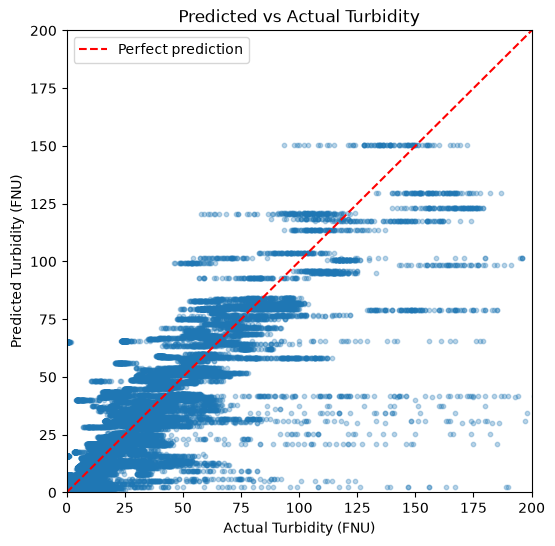

Mean absolute error by test station:
station_nm
WILLOW CREEK RESERVOIR NEAR DAM NEAR GRANBY, CO     26.813206
DES PLAINES RIVER AT ROCKDALE, IL                    8.960033
Lk Houston at FM 1960 nr Huffman, TX                 7.909007
Delaware River at Pennypack Woods PA                 7.310360
FOX RIVER NEAR MCHENRY, IL                           6.326910
MIDDLE FORK WILLAMETTE RIVER AT JASPER, OR           4.323711
BLUE MESA RESERVOIR IN IOLA BASIN NR GUNNISON CO     3.473480
MIDDLE FORK WILLAMETTE RIVER NEAR DEXTER, OR         3.383642
Long Lake at BEN Dock at Long Lake, IL               0.960001
Name: abs_error, dtype: float64

Mean absolute error by basin (huc4):
huc4
1401.0    26.813206
1204.0     7.909007
204.0      7.310360
712.0      5.397983
1709.0     4.222889
1402.0     3.473480
Name: abs_error, dtype: float64


In [33]:
import matplotlib.pyplot as plt

pred_v3_final = np.expm1(model_v3.predict(X_test_v3))
residuals = y_test_v3.values - pred_v3_final

# Predicted vs Actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test_v3, pred_v3_final, alpha=0.3, s=10)
plt.plot([0, 200], [0, 200], 'r--', label="Perfect prediction")
plt.xlabel("Actual Turbidity (FNU)")
plt.ylabel("Predicted Turbidity (FNU)")
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.title("Predicted vs Actual Turbidity")
plt.legend()
plt.show()

# Residuals vs cloud cover — does image quality affect error?
turb_test_df_v3 = turb_test_df_v3.copy()
turb_test_df_v3["residual"] = residuals
turb_test_df_v3["abs_error"] = np.abs(residuals)

# Residuals by station (which stations does the model struggle with?)
station_errors = turb_test_df_v3.groupby("station_nm")["abs_error"].mean().sort_values(ascending=False)
print("Mean absolute error by test station:")
print(station_errors)

# Residuals by basin
if "huc4" in turb_test_df_v3.columns:
    basin_errors = turb_test_df_v3.groupby("huc4")["abs_error"].mean().sort_values(ascending=False)
    print("\nMean absolute error by basin (huc4):")
    print(basin_errors)

In [34]:
from sklearn.utils import resample

n_bootstrap = 200
bootstrap_r2s = []

y_test_arr = y_test_v3.values
pred_arr = pred_v3_final

for i in range(n_bootstrap):
    idx = resample(np.arange(len(y_test_arr)), random_state=i)
    r2_i = r2_score(y_test_arr[idx], pred_arr[idx])
    bootstrap_r2s.append(r2_i)

bootstrap_r2s = np.array(bootstrap_r2s)
ci_lower = np.percentile(bootstrap_r2s, 2.5)
ci_upper = np.percentile(bootstrap_r2s, 97.5)

print(f"R² = {r2_score(y_test_arr, pred_arr):.4f}")
print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

R² = 0.4254
95% Confidence Interval: [0.4084, 0.4444]


In [35]:
mask = turb_test_df_v3["station_nm"] != "WILLOW CREEK RESERVOIR NEAR DAM NEAR GRANBY, CO"

r2_excl = r2_score(turb_test_df_v3.loc[mask, "MeasurementValue"], pred_v3_final[mask])
mae_excl = mean_absolute_error(turb_test_df_v3.loc[mask, "MeasurementValue"], pred_v3_final[mask])

print(f"R² excluding Willow Creek: {r2_excl:.4f} (full test set was {r2_score(y_test_v3, pred_v3_final):.4f})")
print(f"MAE excluding Willow Creek: {mae_excl:.4f} (full test set was {mean_absolute_error(y_test_v3, pred_v3_final):.4f})")

R² excluding Willow Creek: 0.8251 (full test set was 0.4254)
MAE excluding Willow Creek: 7.0949 (full test set was 10.4190)


In [39]:
unique_stations = turb_train_df_v3["station_nm"].unique().tolist()
print(len(unique_stations), "unique stations")
for s in unique_stations:
    print(s)

35 unique stations
DELAWARE RIVER AT LORDVILLE NY
Delaware River at Montague NJ
Delaware River at Frenchtown NJ
Delaware River at Trenton NJ
Delaware River at Penn's Landing, Philadelphia, PA
Schuylkill River at Norristown, PA
DES PLAINES RIVER AT ROUTE 53 AT JOLIET, IL
DES PLAINES RIVER IN LOCK CHANNEL AT ROCKDALE, IL
ILLINOIS RIVER AT SENECA, IL
FOX RIVER NEAR NEW MUNSTER, WI
ILLINOIS RIVER AT STARVED ROCK, IL
ILLINOIS RIVER AT FLORENCE, IL
Trinity Rv nr Rosser, TX
Trinity Rv at IH 10 nr Wallisville, TX
COLORADO RIVER NEAR KREMMLING, CO
COLORADO RIVER AT CATAMOUNT BRIDGE, CO
COLORADO RIVER NEAR DOTSERO, CO
COLORADO RIVER ABOVE GLENWOOD SPRINGS, CO
COLORADO RIVER ABOVE DIVIDE CREEK NEAR SILT, CO
GUNNISON RIVER AT DELTA, CO
COLORADO RIVER NEAR COLORADO-UTAH STATE LINE
WILLAMETTE RIVER AT OWOSSO BRIDGE AT EUGENE, OR
SOUTH SANTIAM RIVER AT WATERLOO, OR
CLACKAMAS RIVER AT ESTACADA, OR
CLACKAMAS RIVER NEAR OREGON CITY, OR
WILLAMETTE RIVER AT PORTLAND, OR
Lynchburg Res nr CWA Canal Inflow n

In [40]:
river_keywords = ["RIVER", "CREEK", "CRK", "RV", "RIV"]
reservoir_keywords = ["RESERVOIR", "LAKE", "LK", "DAM"]

def classify_station(name):
    name_upper = name.upper()
    is_reservoir = any(kw in name_upper for kw in reservoir_keywords)
    is_river = any(kw in name_upper for kw in river_keywords)
    if is_reservoir and not is_river:
        return "Reservoir/Lake"
    elif is_river:
        return "River"
    else:
        return "Unclear"

station_types = pd.Series([classify_station(s) for s in unique_stations])
print(station_types.value_counts())
print()

print("Reservoir/Lake stations in training data:")
for s in unique_stations:
    if classify_station(s) == "Reservoir/Lake":
        print(" -", s)

River             28
Reservoir/Lake     5
Unclear            2
Name: count, dtype: int64

Reservoir/Lake stations in training data:
 - Lk Hou at Jack's Ditch (Site 2) nr Houston, TX
 - Lk Houston S Union Pacific RR Bridge nr Houston,TX
 - Deal Lake 150 ft east of Main St at Interlaken NJ
 - Lk Hopatcong 9600 ft NE of dam at Hopatcong NJ
 - DETROIT LAKE AT LOG BOOM BEHIND DETROIT DAM, OR


In [42]:
# Identify which training rows are from reservoir/lake stations
reservoir_station_names = [
    "Lk Hou at Jack's Ditch (Site 2) nr Houston, TX",
    "Lk Houston S Union Pacific RR Bridge nr Houston,TX",
    "Deal Lake 150 ft east of Main St at Interlaken NJ",
    "Lk Hopatcong 9600 ft NE of dam at Hopatcong NJ",
    "DETROIT LAKE AT LOG BOOM BEHIND DETROIT DAM, OR",
]

is_reservoir = turb_train_df_v3["station_nm"].isin(reservoir_station_names)
print("Reservoir rows in training:", is_reservoir.sum(), "out of", len(turb_train_df_v3))

# Give reservoir rows more weight during training (e.g., 5x)
sample_weights = np.where(is_reservoir, 5.0, 1.0)

model_weighted = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
model_weighted.fit(X_train_v3, y_train_v3, sample_weight=sample_weights)

pred_weighted = np.expm1(model_weighted.predict(X_test_v3))

# Evaluate: full test set, rivers only, and Willow Creek specifically
r2_full = r2_score(y_test_v3, pred_weighted)
mae_full = mean_absolute_error(y_test_v3, pred_weighted)

mask_no_willow = turb_test_df_v3["station_nm"] != "WILLOW CREEK RESERVOIR NEAR DAM NEAR GRANBY, CO"
r2_rivers = r2_score(turb_test_df_v3.loc[mask_no_willow, "MeasurementValue"], pred_weighted[mask_no_willow])

mask_willow = turb_test_df_v3["station_nm"] == "WILLOW CREEK RESERVOIR NEAR DAM NEAR GRANBY, CO"
mae_willow = mean_absolute_error(turb_test_df_v3.loc[mask_willow, "MeasurementValue"], pred_weighted[mask_willow])

print(f"\nFull test set — R²: {r2_full:.4f}, MAE: {mae_full:.4f}")
print(f"Rivers only — R²: {r2_rivers:.4f}")
print(f"Willow Creek (reservoir) MAE: {mae_willow:.4f} (was 26.81 unweighted)")

Reservoir rows in training: 66198 out of 203283

Full test set — R²: 0.4098, MAE: 9.9814
Rivers only — R²: 0.8331
Willow Creek (reservoir) MAE: 26.5044 (was 26.81 unweighted)


In [43]:
# Combine ALL reservoir stations (train + test) so we can test each one held out individually
all_reservoir_names = [
    "Lk Hou at Jack's Ditch (Site 2) nr Houston, TX",
    "Lk Houston S Union Pacific RR Bridge nr Houston,TX",
    "Deal Lake 150 ft east of Main St at Interlaken NJ",
    "Lk Hopatcong 9600 ft NE of dam at Hopatcong NJ",
    "DETROIT LAKE AT LOG BOOM BEHIND DETROIT DAM, OR",
    "WILLOW CREEK RESERVOIR NEAR DAM NEAR GRANBY, CO",
]

df_all_turbidity = pd.concat([turb_train_df_v3, turb_test_df_v3], ignore_index=True)
df_reservoirs_only = df_all_turbidity[df_all_turbidity["station_nm"].isin(all_reservoir_names)]
df_rivers_only = df_all_turbidity[~df_all_turbidity["station_nm"].isin(all_reservoir_names)]

print("Total reservoir rows:", len(df_reservoirs_only))
print("Reservoir stations found:", df_reservoirs_only["station_nm"].unique())

# Leave-one-reservoir-out: train on rivers + all-but-one reservoir, test on the held-out reservoir
results_loro = []

for held_out_station in all_reservoir_names:
    train_mask = df_all_turbidity["station_nm"] != held_out_station
    test_mask = df_all_turbidity["station_nm"] == held_out_station

    if test_mask.sum() == 0:
        print(f"Skipping {held_out_station} — no rows found")
        continue

    X_tr = df_all_turbidity.loc[train_mask, feature_cols_v3].fillna(0)
    y_tr = np.log1p(df_all_turbidity.loc[train_mask, "MeasurementValue"].clip(upper=cap_value))

    X_te = df_all_turbidity.loc[test_mask, feature_cols_v3].fillna(0)
    y_te = df_all_turbidity.loc[test_mask, "MeasurementValue"]

    m = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
    m.fit(X_tr, y_tr)
    pred = np.expm1(m.predict(X_te))

    mae = mean_absolute_error(y_te, pred)
    results_loro.append({"station": held_out_station, "n_rows": test_mask.sum(), "MAE": mae})
    print(f"{held_out_station}: MAE = {mae:.2f} (n={test_mask.sum()})")

results_loro_df = pd.DataFrame(results_loro)
print("\n", results_loro_df)

Total reservoir rows: 74133
Reservoir stations found: <ArrowStringArray>
[    'Lk Hou at Jack's Ditch (Site 2) nr Houston, TX',
 'Lk Houston S Union Pacific RR Bridge nr Houston,TX',
  'Deal Lake 150 ft east of Main St at Interlaken NJ',
     'Lk Hopatcong 9600 ft NE of dam at Hopatcong NJ',
    'DETROIT LAKE AT LOG BOOM BEHIND DETROIT DAM, OR',
    'WILLOW CREEK RESERVOIR NEAR DAM NEAR GRANBY, CO']
Length: 6, dtype: str
Lk Hou at Jack's Ditch (Site 2) nr Houston, TX: MAE = 7.93 (n=22534)
Lk Houston S Union Pacific RR Bridge nr Houston,TX: MAE = 6.24 (n=38230)
Deal Lake 150 ft east of Main St at Interlaken NJ: MAE = 6.19 (n=825)
Lk Hopatcong 9600 ft NE of dam at Hopatcong NJ: MAE = 1.64 (n=843)
DETROIT LAKE AT LOG BOOM BEHIND DETROIT DAM, OR: MAE = 1.87 (n=3766)
WILLOW CREEK RESERVOIR NEAR DAM NEAR GRANBY, CO: MAE = 26.81 (n=7935)

                                              station  n_rows        MAE
0     Lk Hou at Jack's Ditch (Site 2) nr Houston, TX   22534   7.929571
1  Lk Houst

In [44]:
willow_data = df_all_turbidity[df_all_turbidity["station_nm"] == "WILLOW CREEK RESERVOIR NEAR DAM NEAR GRANBY, CO"]
print(willow_data["MeasurementValue"].describe())

count    7935.000000
mean       34.630309
std        72.134861
min         0.800000
25%         3.100000
50%         8.200000
75%        22.400000
max       470.000000
Name: MeasurementValue, dtype: float64


In [45]:
exclude_station = "WILLOW CREEK RESERVOIR NEAR DAM NEAR GRANBY, CO"

turb_train_df_clean = turb_train_df_v3[turb_train_df_v3["station_nm"] != exclude_station]
turb_test_df_clean = turb_test_df_v3[turb_test_df_v3["station_nm"] != exclude_station]

X_train_clean = turb_train_df_clean[feature_cols_v3].fillna(0)
y_train_clean = np.log1p(turb_train_df_clean["MeasurementValue"].clip(upper=cap_value))

X_test_clean = turb_test_df_clean[feature_cols_v3].fillna(0)
y_test_clean = turb_test_df_clean["MeasurementValue"]

model_clean = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
model_clean.fit(X_train_clean, y_train_clean)

pred_clean = np.expm1(model_clean.predict(X_test_clean))

print("R² (Willow Creek excluded):", r2_score(y_test_clean, pred_clean))
print("MAE (Willow Creek excluded):", mean_absolute_error(y_test_clean, pred_clean))

R² (Willow Creek excluded): 0.8250795772056354
MAE (Willow Creek excluded): 7.09487656070092
